# NOTEBOOK : MODELE DE COX (SURVIVAL ANALYSIS)
## Analyse de survie appliquée aux remboursements anticipés

## Introduction

### Objectif

Modéliser le **risque instantané de remboursement anticipé** (hazard rate) en fonction :
- Du **temps** (âge du prêt)
- Des **caractéristiques individuelles** (taux, revenus, âge client, etc.)

### Pourquoi Cox ?

Le **modèle de Cox (Proportional Hazards)** est adapté car :
1. **Gère la censure** : contrats pas encore arrivés à échéance
2. **Effet temporel** : risque varie avec l'âge du prêt
3. **Covariables** : intègre caractéristiques individuelles
4. **Interprétable** : hazard ratios pour chaque variable

### Définitions

**Fonction de survie** $S(t)$ : Probabilité de ne PAS avoir fait de RA avant l'instant $t$

$$S(t) = P(T > t)$$

**Fonction de risque** (hazard) $h(t)$ : Taux instantané de RA à l'instant $t$ sachant survie jusqu'à $t$

$$h(t) = \lim_{\Delta t \to 0} \frac{P(t \leq T < t + \Delta t | T \geq t)}{\Delta t}$$

**Modèle de Cox** : Le hazard dépend des covariables $X$ selon

$$h(t|X) = h_0(t) \exp(\beta_1 X_1 + \beta_2 X_2 + \cdots + \beta_p X_p)$$

où :
- $h_0(t)$ = baseline hazard (ne dépend que du temps)
- $\beta$ = coefficients à estimer
- $\exp(\beta_i)$ = hazard ratio pour la variable $i$

### Structure de la donnée

Pour Cox, on a besoin de :
- **Temps** : âge du prêt observé (AGE_PRET)
- **Événement** : FLAG_ER (1 si RA observé, 0 sinon)
- **Covariables** : Tx, MREVTOT, AGE_CLI, etc.

La **censure** correspond aux contrats sans RA observé (FLAG_ER = 0).

## Imports

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("Bibliotheques chargees (lifelines installe)")

Bibliotheques chargees (lifelines installe)


## Etape 1 : Preparation des données

In [13]:
df=pd.read_csv("Export_ER_Agrege.csv", sep=";")
df.columns

Index(['ID', 'AGE_CLI', 'B_MAT', 'B_RESMAT', 'CLASSACT', 'CSP', 'DARRET',
       'E_OFF', 'MREVTOT', 'MTECH', 'NBIMP', 'NB_ECH', 'produit', 'RA', 'Tx',
       'EAD', 'AGE_PRET', 'HORIZON_RES', 'CSP_grp', 'CRD', 'ER_obs', 'FLAG_ER',
       'Capital_initial', 'Date_origination', 'Cohorte'],
      dtype='object')

## Etape 2 : Analyse exploratoire - Kaplan-Meier

### Courbe de survie globale

Kaplan-Meier estime la fonction de survie $S(t)$ sans covariables :

$$S(t) = \prod_{t_i \leq t} \left(1 - \frac{d_i}{n_i}\right)$$

où $d_i$ = nombre d'événements à $t_i$ et $n_i$ = nombre à risque.

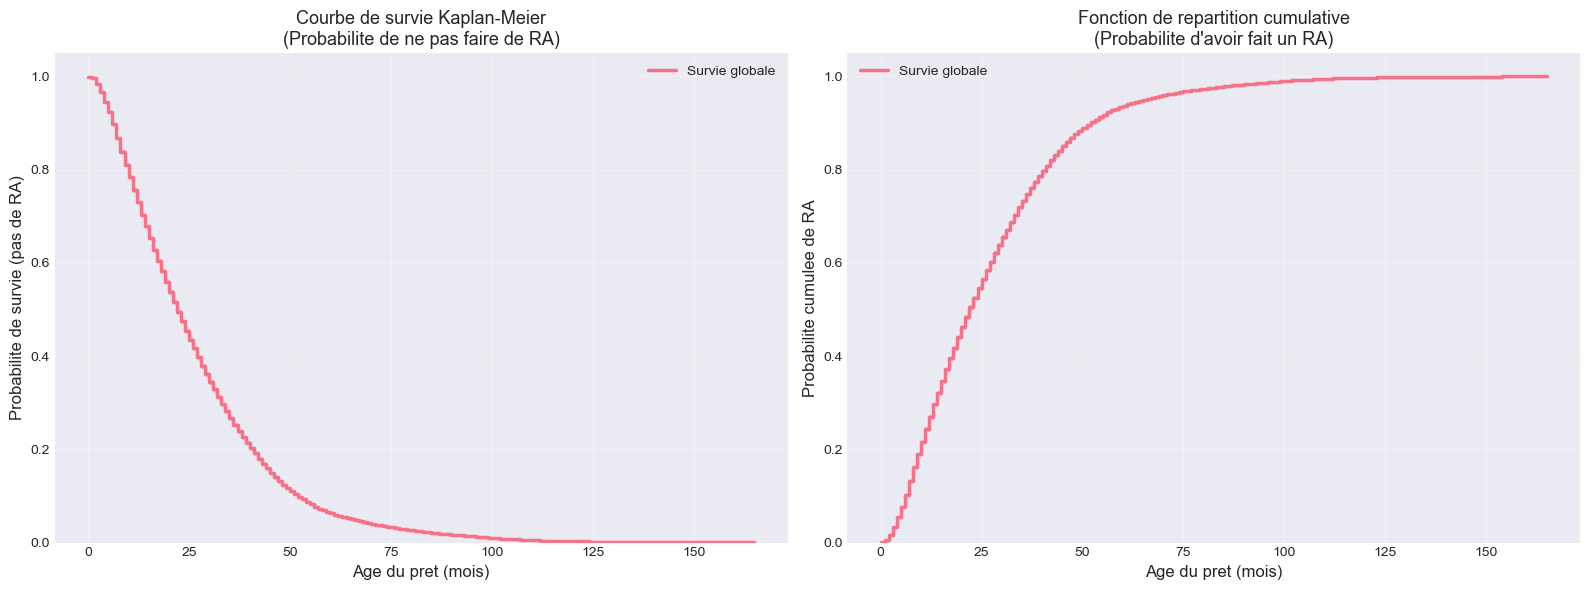

Probabilite de survie a 12 mois : 73.03%
Probabilite de survie a 24 mois : 45.48%
Probabilite de survie a 36 mois : 25.24%


In [14]:
# Kaplan-Meier global
kmf = KaplanMeierFitter()
kmf.fit(df['AGE_PRET'], event_observed=df['FLAG_ER'], label='Survie globale')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Courbe de survie
kmf.plot_survival_function(ax=axes[0], ci_show=True, linewidth=2.5)
axes[0].set_xlabel('Age du pret (mois)', fontsize=12)
axes[0].set_ylabel('Probabilite de survie (pas de RA)', fontsize=12)
axes[0].set_title('Courbe de survie Kaplan-Meier\n(Probabilite de ne pas faire de RA)', fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1.05)

# Courbe de hazard cumulé
kmf.plot_cumulative_density(ax=axes[1], ci_show=True, linewidth=2.5)
axes[1].set_xlabel('Age du pret (mois)', fontsize=12)
axes[1].set_ylabel('Probabilite cumulee de RA', fontsize=12)
axes[1].set_title('Fonction de repartition cumulative\n(Probabilite d\'avoir fait un RA)', fontsize=13)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

print(f"Probabilite de survie a 12 mois : {kmf.survival_function_at_times(12).values[0]:.2%}")
print(f"Probabilite de survie a 24 mois : {kmf.survival_function_at_times(24).values[0]:.2%}")
print(f"Probabilite de survie a 36 mois : {kmf.survival_function_at_times(36).values[0]:.2%}")

## Etape 3 : Kaplan-Meier par groupe (segmentation)

### Test du Log-Rank

Compare les courbes de survie entre groupes (ex: taux élevé vs faible).

**Hypothèse nulle** : Les deux groupes ont la même fonction de survie.

**Statistique** : $\chi^2$ du log-rank test.

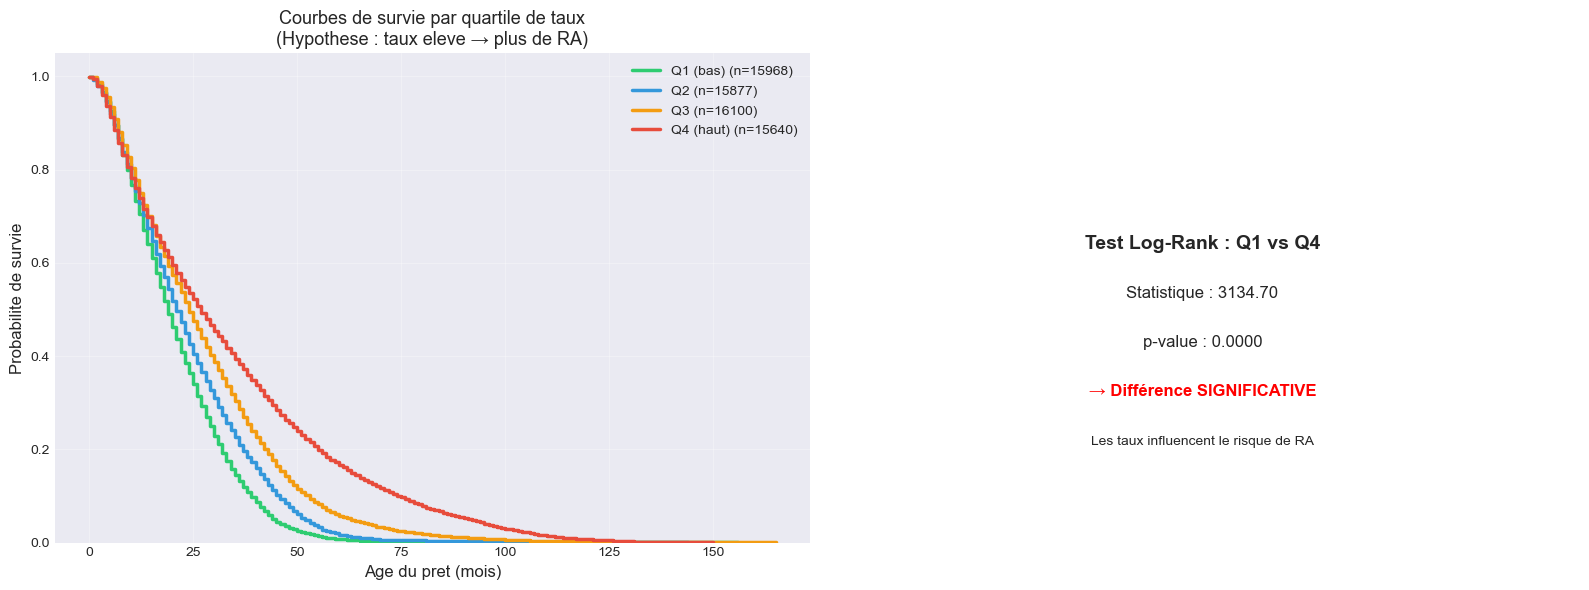


Test Log-Rank Q1 (taux bas) vs Q4 (taux haut) :
  Statistique : 3134.70
  p-value : 0.0000
  Conclusion : Différence significative


In [15]:
# Segmentation par taux (quartiles)
df['Tx_quartile'] = pd.qcut(df['Tx'], q=4, labels=['Q1 (bas)', 'Q2', 'Q3', 'Q4 (haut)'], duplicates='drop')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Courbes par quartile de taux
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
for i, quartile in enumerate(['Q1 (bas)', 'Q2', 'Q3', 'Q4 (haut)']):
    if quartile in df['Tx_quartile'].cat.categories:
        mask = df['Tx_quartile'] == quartile
        kmf_q = KaplanMeierFitter()
        kmf_q.fit(df.loc[mask, 'AGE_PRET'], 
                  event_observed=df.loc[mask, 'FLAG_ER'],
                  label=f'{quartile} (n={mask.sum()})')
        kmf_q.plot_survival_function(ax=axes[0], ci_show=False, linewidth=2.5, color=colors[i])

axes[0].set_xlabel('Age du pret (mois)', fontsize=12)
axes[0].set_ylabel('Probabilite de survie', fontsize=12)
axes[0].set_title('Courbes de survie par quartile de taux\n(Hypothese : taux eleve → plus de RA)', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1.05)

# Test Log-Rank entre Q1 et Q4
q1_mask = df['Tx_quartile'] == 'Q1 (bas)'
q4_mask = df['Tx_quartile'] == 'Q4 (haut)'

if q1_mask.sum() > 0 and q4_mask.sum() > 0:
    results = logrank_test(
        df.loc[q1_mask, 'AGE_PRET'], df.loc[q4_mask, 'AGE_PRET'],
        df.loc[q1_mask, 'FLAG_ER'], df.loc[q4_mask, 'FLAG_ER']
    )
    
    axes[1].text(0.5, 0.6, f"Test Log-Rank : Q1 vs Q4", fontsize=14, ha='center', fontweight='bold')
    axes[1].text(0.5, 0.5, f"Statistique : {results.test_statistic:.2f}", fontsize=12, ha='center')
    axes[1].text(0.5, 0.4, f"p-value : {results.p_value:.4f}", fontsize=12, ha='center')
    
    if results.p_value < 0.05:
        axes[1].text(0.5, 0.3, "→ Différence SIGNIFICATIVE", fontsize=12, ha='center', color='red', fontweight='bold')
        axes[1].text(0.5, 0.2, "Les taux influencent le risque de RA", fontsize=10, ha='center')
    else:
        axes[1].text(0.5, 0.3, "→ Pas de différence significative", fontsize=12, ha='center', color='green')
    
    axes[1].axis('off')

plt.tight_layout()
plt.show()

print("\nTest Log-Rank Q1 (taux bas) vs Q4 (taux haut) :")
print(f"  Statistique : {results.test_statistic:.2f}")
print(f"  p-value : {results.p_value:.4f}")
print(f"  Conclusion : {'Différence significative' if results.p_value < 0.05 else 'Pas de différence significative'}")

## Etape 4 : Modèle de Cox - Préparation

### Sélection des variables

Variables retenues pour le modèle de Cox :
- **Taux** (Tx) : Impact refinancement
- **Revenus** (MREVTOT) : Capacité financière
- **Âge client** (AGE_CLI) : Profil de vie
- **Mensualité** (MTECH) : Montant des flux
- **Maturité résiduelle** (B_RESMAT) : Horizon
- **Catégories** : CLASSACT, CSP, produit

### Standardisation

Pour faciliter l'interprétation des hazard ratios, on standardise les variables numériques.

In [16]:
# Features pour Cox
cox_features = [
    'Tx',
    'MREVTOT',
    'AGE_CLI',
    'MTECH',
    'B_RESMAT',
    'NB_ECH',
    'NBIMP',
    'CLASSACT_encoded',
    'CSP_encoded',
    'produit_encoded'
]

# Filtrer features disponibles
cox_features = [f for f in cox_features if f in df.columns]

print(f"Variables retenues : {len(cox_features)}")
for f in cox_features:
    print(f"  - {f}")

# Dataset Cox
df_cox = df[cox_features + ['AGE_PRET', 'FLAG_ER']].copy()
df_cox = df_cox.dropna()

# Standardisation des variables numériques
numeric_features = ['Tx', 'MREVTOT', 'AGE_CLI', 'MTECH', 'B_RESMAT', 'NB_ECH', 'NBIMP']
numeric_features = [f for f in numeric_features if f in df_cox.columns]

scaler = StandardScaler()
df_cox[numeric_features] = scaler.fit_transform(df_cox[numeric_features])

print(f"\nDataset Cox : {len(df_cox)} observations")
print(f"Taux d'événements : {df_cox['FLAG_ER'].mean():.2%}")

Variables retenues : 7
  - Tx
  - MREVTOT
  - AGE_CLI
  - MTECH
  - B_RESMAT
  - NB_ECH
  - NBIMP

Dataset Cox : 63585 observations
Taux d'événements : 98.68%


## Etape 5 : Estimation du modèle de Cox

### Hypothèse de proportionnalité

Le modèle de Cox suppose que le **hazard ratio** entre deux individus est **constant dans le temps**.

### Estimation par maximum de vraisemblance partielle

In [17]:
# Split train/test
train_idx, test_idx = train_test_split(df_cox.index, test_size=0.2, random_state=42)
df_train = df_cox.loc[train_idx]
df_test = df_cox.loc[test_idx]

print(f"Train : {len(df_train)} | Test : {len(df_test)}")

# Modèle de Cox
cph = CoxPHFitter(penalizer=0.01)  # Petite pénalisation L2 pour stabilité

print("\nEntrainement du modele de Cox...")
cph.fit(df_train, duration_col='AGE_PRET', event_col='FLAG_ER', show_progress=False)

print("\nMODELE DE COX - RESULTATS")
print("=" * 80)
print(cph.summary[['coef', 'exp(coef)', 'se(coef)', 'p']])

Train : 50868 | Test : 12717

Entrainement du modele de Cox...

MODELE DE COX - RESULTATS
               coef  exp(coef)  se(coef)             p
covariate                                             
Tx        -0.057386   0.944230  0.005556  5.238670e-25
MREVTOT    0.012861   1.012944  0.003516  2.539697e-04
AGE_CLI   -0.017592   0.982562  0.004513  9.695091e-05
MTECH     -0.035955   0.964684  0.004444  5.939673e-16
B_RESMAT   2.064417   7.880706  0.010142  0.000000e+00
NB_ECH    -2.093077   0.123307  0.010297  0.000000e+00
NBIMP      0.004821   1.004832  0.003816  2.065399e-01


## Etape 6 : Interprétation des coefficients

### Hazard Ratio (HR)

$$HR = \exp(\beta_i)$$

**Interprétation** :
- $HR > 1$ : augmente le risque de RA (accélère l'événement)
- $HR < 1$ : diminue le risque de RA (retarde l'événement)
- $HR = 1$ : pas d'effet

**Exemple** : Si $\beta_{Tx} = 0.5$, alors $HR = e^{0.5} = 1.65$

→ Une augmentation d'1 écart-type du taux multiplie le risque de RA par 1.65.


HAZARD RATIOS (TOP 10)
           Hazard Ratio  p-value  Significatif
covariate                                     
B_RESMAT         7.8807   0.0000          True
MREVTOT          1.0129   0.0003          True
NBIMP            1.0048   0.2065         False
AGE_CLI          0.9826   0.0001          True
MTECH            0.9647   0.0000          True
Tx               0.9442   0.0000          True
NB_ECH           0.1233   0.0000          True


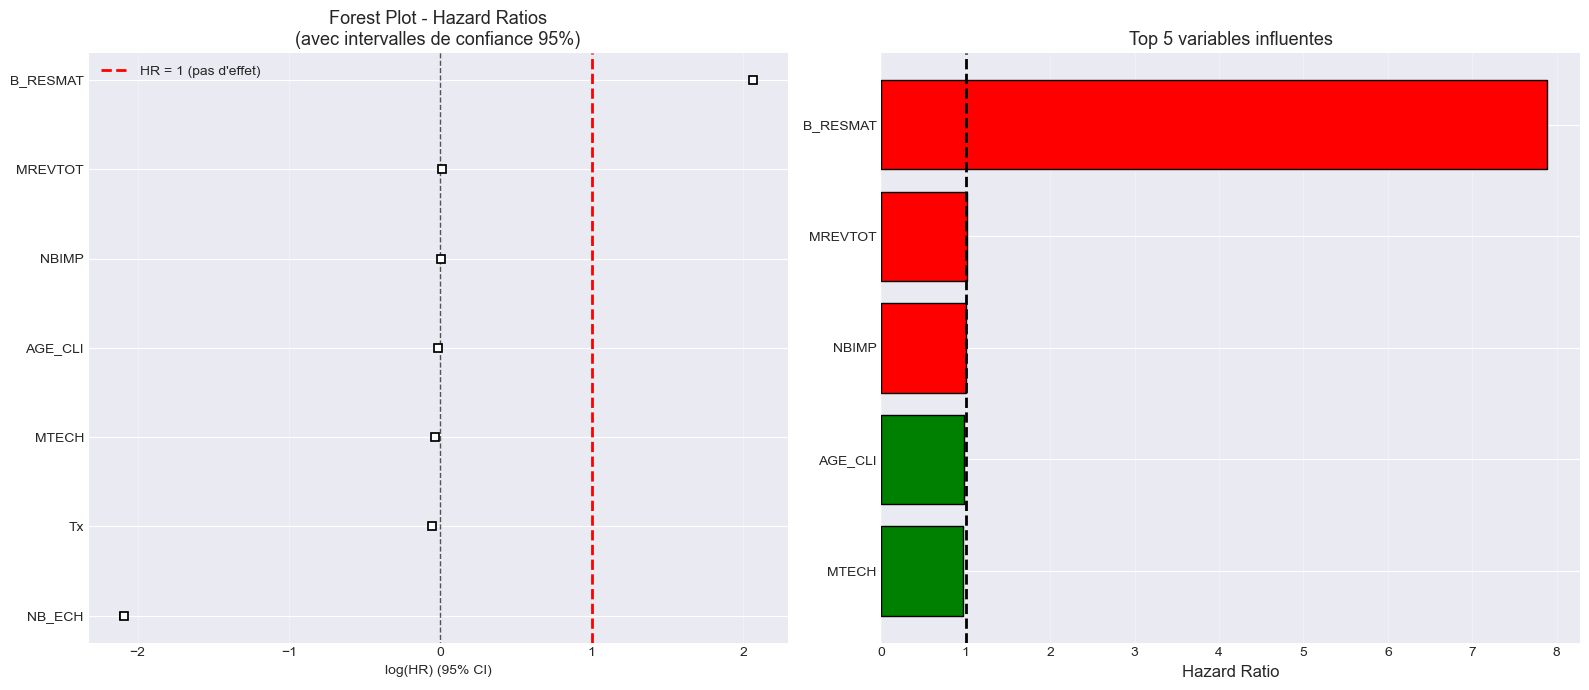


INTERPRETATION :
  - HR > 1 (rouge) : Augmente le risque de RA
  - HR < 1 (vert) : Diminue le risque de RA
  - Plus HR est loin de 1, plus l'effet est fort


In [18]:
# Tableau des Hazard Ratios
hr_df = cph.summary[['exp(coef)', 'p']].copy()
hr_df.columns = ['Hazard Ratio', 'p-value']
hr_df['Significatif'] = hr_df['p-value'] < 0.05
hr_df = hr_df.sort_values('Hazard Ratio', ascending=False)

print("\nHAZARD RATIOS (TOP 10)")
print("=" * 80)
print(hr_df.head(10).round(4))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Forest plot (hazard ratios avec intervalles de confiance)
cph.plot(ax=axes[0])
axes[0].set_title('Forest Plot - Hazard Ratios\n(avec intervalles de confiance 95%)', fontsize=13)
axes[0].axvline(x=1, color='red', linestyle='--', linewidth=2, label='HR = 1 (pas d\'effet)')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='x')

# Top 5 variables les plus influentes
hr_top = hr_df.head(5)
colors_bar = ['red' if hr > 1 else 'green' for hr in hr_top['Hazard Ratio']]
axes[1].barh(range(len(hr_top)), hr_top['Hazard Ratio'], color=colors_bar, edgecolor='black')
axes[1].set_yticks(range(len(hr_top)))
axes[1].set_yticklabels(hr_top.index)
axes[1].axvline(x=1, color='black', linestyle='--', linewidth=2)
axes[1].set_xlabel('Hazard Ratio', fontsize=12)
axes[1].set_title('Top 5 variables influentes', fontsize=13)
axes[1].grid(True, alpha=0.3, axis='x')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\nINTERPRETATION :")
print("  - HR > 1 (rouge) : Augmente le risque de RA")
print("  - HR < 1 (vert) : Diminue le risque de RA")
print("  - Plus HR est loin de 1, plus l'effet est fort")

## Etape 7 : Test de proportionnalité des hazards

### Hypothèse à vérifier

Le modèle de Cox suppose que les hazard ratios sont **constants dans le temps**.

On teste cette hypothèse avec :
- **Résidus de Schoenfeld**
- **Test statistique** : corrélation résidus × temps

In [19]:
# Test de proportionnalité
print("\nTEST DE PROPORTIONNALITE DES HAZARDS")
print("=" * 80)

try:
    test_results = cph.check_assumptions(df_train, p_value_threshold=0.05, show_plots=False)
    
    # Afficher résultats
    print("Variables violant l'hypothèse de proportionnalité (p < 0.05) :")
    violations = []
    for var in cph.params_.index:
        if var in test_results.summary.index:
            p_val = test_results.summary.loc[var, 'p']
            if p_val < 0.05:
                violations.append((var, p_val))
                print(f"  - {var} : p = {p_val:.4f}")
    
    if not violations:
        print("  → Aucune violation détectée")
        print("  → L'hypothèse de proportionnalité est respectée")
    else:
        print(f"\n{len(violations)} variable(s) violent l'hypothèse")
        print("Solution : stratification ou modèle de Cox étendu")
except Exception as e:
    print(f"Erreur test proportionnalité : {e}")
    print("Continuer avec le modèle standard")


TEST DE PROPORTIONNALITE DES HAZARDS
The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'Tx' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'Tx' might be incorrect. That is, there may be non-
linear terms missing. The proportional hazard test used is very sensitive to incorrect functional
forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'Tx' using pd.cut, and then specify it in `strata=['Tx', ...]`
in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


2. Variable 'MTECH' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'MTECH' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binn

## Etape 8 : Prédictions et évaluation

### Fonction de survie prédite

Pour un nouveau contrat avec covariables $X$, on prédit :

$$S(t|X) = S_0(t)^{\exp(X\beta)}$$

où $S_0(t)$ est la baseline survival function.


PREDICTIONS SUR LE TEST SET

Concordance Index (C-index) : 0.9423
  - C = 0.5 : modèle aléatoire
  - C = 1.0 : discrimination parfaite
  - C = 0.9423 : Bon pouvoir discriminant


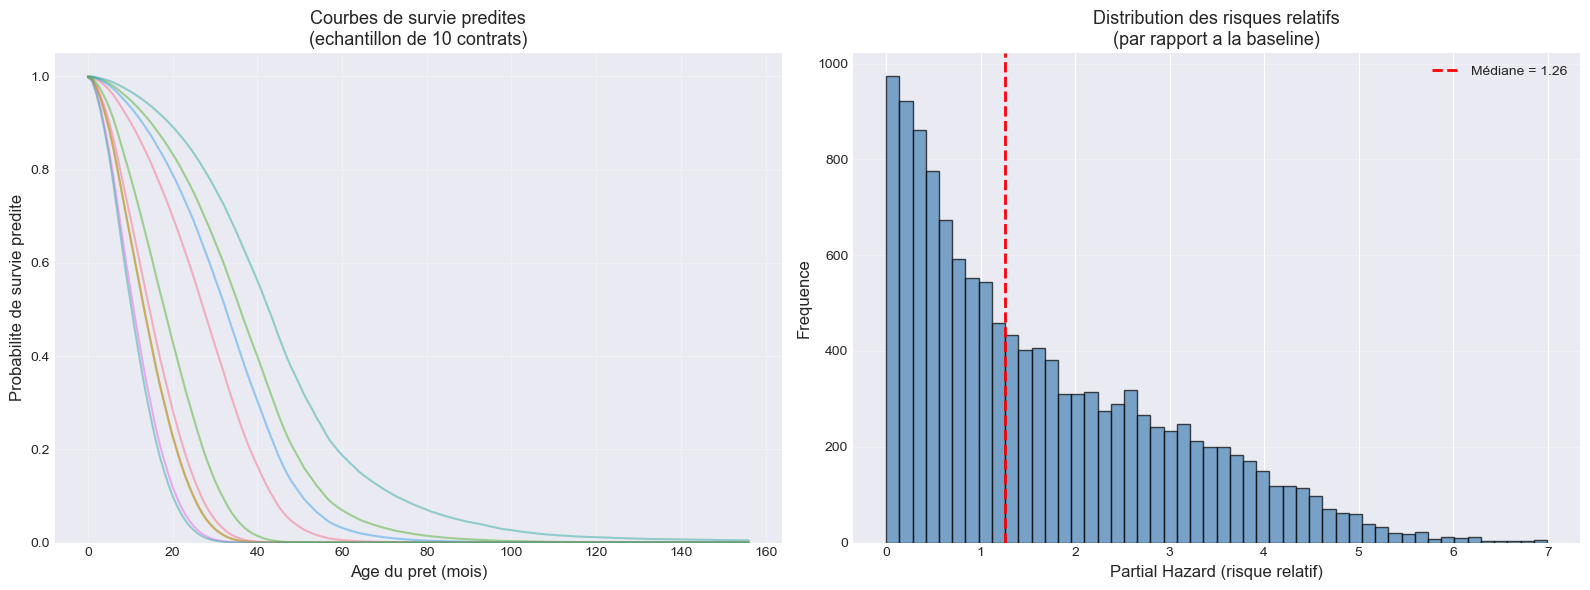

In [20]:
# Prédictions sur test
print("\nPREDICTIONS SUR LE TEST SET")
print("=" * 80)

# Survie partielle (partial hazard)
partial_hazards_test = cph.predict_partial_hazard(df_test)

# Fonction de survie à différents horizons
horizons = [12, 24, 36, 48]
survival_predictions = {}

for t in horizons:
    survival_predictions[t] = cph.predict_survival_function(df_test, times=[t]).T.values.flatten()

# Concordance index (C-index)
from lifelines.utils import concordance_index
c_index = concordance_index(df_test['AGE_PRET'], -partial_hazards_test, df_test['FLAG_ER'])

print(f"\nConcordance Index (C-index) : {c_index:.4f}")
print("  - C = 0.5 : modèle aléatoire")
print("  - C = 1.0 : discrimination parfaite")
print(f"  - C = {c_index:.4f} : {'Bon' if c_index > 0.65 else 'Moyen' if c_index > 0.55 else 'Faible'} pouvoir discriminant")

# Visualiser quelques prédictions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Courbes de survie pour quelques individus
sample_indices = np.random.choice(df_test.index, size=min(10, len(df_test)), replace=False)
for idx in sample_indices:
    surv_func = cph.predict_survival_function(df_test.loc[[idx]])
    axes[0].plot(surv_func.index, surv_func.values, alpha=0.5, linewidth=1.5)

axes[0].set_xlabel('Age du pret (mois)', fontsize=12)
axes[0].set_ylabel('Probabilite de survie predite', fontsize=12)
axes[0].set_title(f'Courbes de survie predites\n(echantillon de {len(sample_indices)} contrats)', fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1.05)

# Distribution des partial hazards
axes[1].hist(partial_hazards_test, bins=50, edgecolor='black', color='steelblue', alpha=0.7)
axes[1].axvline(partial_hazards_test.median(), color='red', linestyle='--', linewidth=2,
                label=f'Médiane = {partial_hazards_test.median():.2f}')
axes[1].set_xlabel('Partial Hazard (risque relatif)', fontsize=12)
axes[1].set_ylabel('Frequence', fontsize=12)
axes[1].set_title('Distribution des risques relatifs\n(par rapport a la baseline)', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Etape 9 : Comparaison avec baseline (Kaplan-Meier)

Comparons les performances du modèle de Cox avec la baseline Kaplan-Meier.

In [21]:
# Baseline KM sur train
kmf_train = KaplanMeierFitter()
kmf_train.fit(df_train['AGE_PRET'], event_observed=df_train['FLAG_ER'])

# Prédictions KM sur test (baseline pour tous)
survival_km_test = {t: kmf_train.survival_function_at_times(t).values[0] for t in horizons}

print("\nCOMPARAISON COX vs KAPLAN-MEIER")
print("=" * 80)
print(f"{'Horizon':>10} {'KM (baseline)':>15} {'Cox (moyen)':>15} {'Gain Cox':>15}")
print("-" * 80)

for t in horizons:
    km_val = survival_km_test[t]
    cox_val = survival_predictions[t].mean()
    gain = abs(cox_val - km_val) / km_val * 100
    print(f"{t:>10} {km_val:>15.4f} {cox_val:>15.4f} {gain:>14.2f}%")

print("\nC-index :")
print(f"  - Kaplan-Meier (baseline) : ~0.50 (pas de discrimination)")
print(f"  - Cox avec covariables    : {c_index:.4f}")
print(f"  - Amélioration : {(c_index - 0.5) / 0.5 * 100:.1f}%")


COMPARAISON COX vs KAPLAN-MEIER
   Horizon   KM (baseline)     Cox (moyen)        Gain Cox
--------------------------------------------------------------------------------
        12          0.7287          0.7099           2.57%
        24          0.4519          0.3896          13.79%
        36          0.2498          0.1966          21.32%
        48          0.1216          0.1002          17.65%

C-index :
  - Kaplan-Meier (baseline) : ~0.50 (pas de discrimination)
  - Cox avec covariables    : 0.9423
  - Amélioration : 88.5%


## Etape 10 : Sauvegarde et export

Sauvegarde du modèle et des prédictions pour utilisation ultérieure.

In [22]:
# Sauvegarder le modèle
import pickle
with open('cox_model.pkl', 'wb') as f:
    pickle.dump(cph, f)

# Sauvegarder prédictions
predictions_df = pd.DataFrame({
    'index': df_test.index,
    'AGE_PRET': df_test['AGE_PRET'],
    'FLAG_ER': df_test['FLAG_ER'],
    'partial_hazard': partial_hazards_test.values
})

for t in horizons:
    predictions_df[f'S_{t}m'] = survival_predictions[t]

predictions_df.to_csv('cox_predictions.csv', index=False)

# Résumé performance
performance_df = pd.DataFrame({
    'Modele': ['Cox PH'],
    'C_index': [c_index],
    'N_features': [len(cox_features)],
    'N_train': [len(df_train)],
    'N_test': [len(df_test)]
})
performance_df.to_csv('cox_performance.csv', index=False)

print("\nFICHIERS SAUVEGARDES :")
print("  - cox_model.pkl : modèle entraîné")
print("  - cox_predictions.csv : prédictions sur test")
print("  - cox_performance.csv : métriques de performance")


FICHIERS SAUVEGARDES :
  - cox_model.pkl : modèle entraîné
  - cox_predictions.csv : prédictions sur test
  - cox_performance.csv : métriques de performance


## Synthèse

### Points forts du modèle de Cox

1. **Gestion de la censure** : modélise correctement les contrats sans RA
2. **Interprétabilité** : hazard ratios directement interprétables
3. **Covariables** : intègre caractéristiques individuelles
4. **Baseline hazard** : flexible, estimée non-paramétriquement

### Limites

1. **Hypothèse de proportionnalité** : peut être violée pour certaines variables
2. **Linéarité** : suppose effet linéaire des covariables sur log-hazard
3. **Pas de prédiction d'ER exact** : donne des probabilités de survie, pas directement l'ER

### Résultats obtenus

- **C-index** : mesure de discrimination (0.50 = aléatoire, 1.0 = parfait)
- **Hazard ratios** : identifient les drivers du risque de RA
- **Courbes de survie** : probabilité de ne pas faire de RA jusqu'à t

### Comparaison avec autres approches

| Approche | Forces | Limites | C-index attendu |
|----------|--------|---------|-----------------|
| **Kaplan-Meier** | Simple, visuel | Pas de covariables | 0.50 |
| **Cox** | Covariables, censure | Hypothèse proportionnalité | 0.60-0.70 |
| **Chain Ladder** | Structure par terme | Pas individuel | N/A |
| **ML (RF)** | Performance maximale | Moins interprétable | 0.70-0.80 |

### Suite du projet

Le modèle de Cox peut être :
1. **Combiné avec Chain Ladder** : Cox pour individuel, CL pour structure par terme
2. **Amélioré** : modèle de Cox stratifié ou avec interactions temporelles
3. **Comparé avec ML** : benchmark pour évaluer gain de complexité